In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Reviews.csv')

print("--- Verinin İlk 5 Satırı ---")
print(df.head())

print("\n--- Eksik Değer Sayıları ---")
print(df.isnull().sum())

--- Verinin İlk 5 Satırı ---
   Id   ProductId          UserId                      ProfileName  \
0   1  B001E4KFG0  A3SGXH7AUHU8GW                       delmartian   
1   2  B00813GRG4  A1D87F6ZCVE5NK                           dll pa   
2   3  B000LQOCH0   ABXLMWJIXXAIN  Natalia Corres "Natalia Corres"   
3   4  B000UA0QIQ  A395BORC6FGVXV                             Karl   
4   5  B006K2ZZ7K  A1UQRSCLF8GW1T    Michael D. Bigham "M. Wassir"   

   HelpfulnessNumerator  HelpfulnessDenominator  Score        Time  \
0                     1                       1      5  1303862400   
1                     0                       0      1  1346976000   
2                     1                       1      4  1219017600   
3                     3                       3      2  1307923200   
4                     0                       0      5  1350777600   

                 Summary                                               Text  
0  Good Quality Dog Food  I have bought several of 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_25836\2936203149.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Score', palette='viridis')


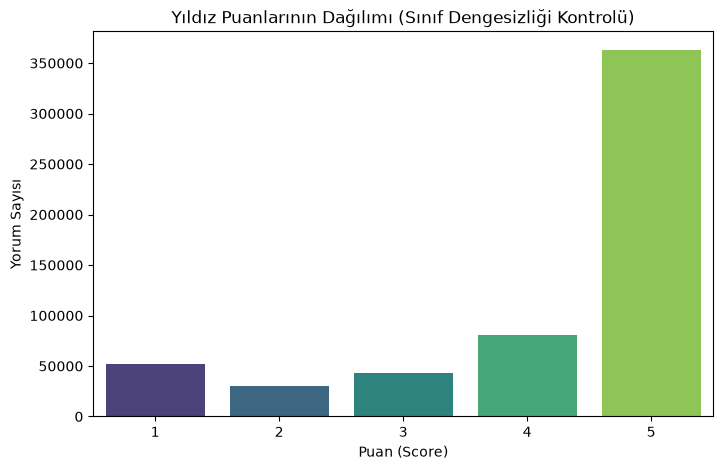

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Score', palette='viridis')
plt.title('Yıldız Puanlarının Dağılımı (Sınıf Dengesizliği Kontrolü)')
plt.xlabel('Puan (Score)')
plt.ylabel('Yorum Sayısı')
plt.show()

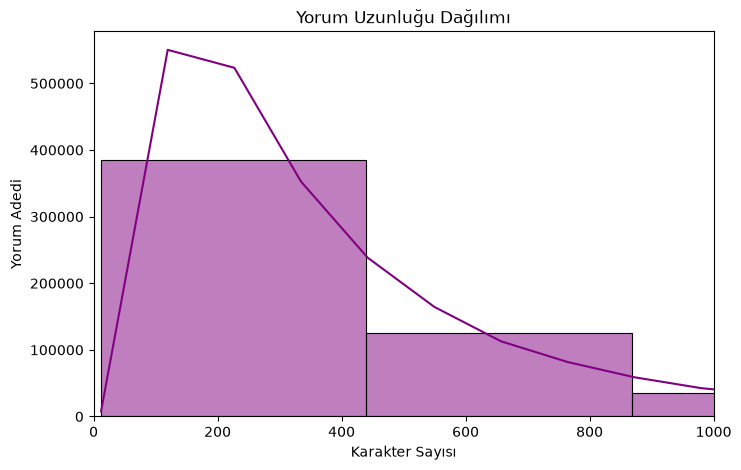

In [ ]:
df['review_length'] = df['Text'].apply(lambda x: len(str(x)))

plt.figure(figsize=(8, 5))
sns.histplot(df['review_length'], bins=50, kde=True, color='purple')
plt.title('Yorum Uzunluğu Dağılımı')
plt.xlabel('Karakter Sayısı')
plt.ylabel('Yorum Adedi')
plt.xlim(0, 1000) 
plt.show()

In [ ]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    words = text.split()
    
    cleaned_words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    
    return " ".join(cleaned_words)

df['cleaned_text'] = df['Text'].apply(clean_text)

print("Metin ön işleme başarıyla tamamlandı! Yeni sütun: 'cleaned_text'")

Metin ön işleme başarıyla tamamlandı! Yeni sütun: 'cleaned_text'


In [ ]:
ornek_metin = "The product was AMAZING!! I am absolutely loving it, bought 2 days ago."

print("1. Ham Hali:", ornek_metin)

adim_1 = re.sub(r'[^a-zA-Z\s]', '', ornek_metin.lower())
print("\n2. Küçük Harf ve Noktalamasız:", adim_1)

adim_2 = [word for word in adim_1.split() if word not in stop_words]
print("\n3. Stop Words Temizlenmiş Hali:", adim_2)

adim_3 = [lemmatizer.lemmatize(word) for word in adim_2]
print("\n4. Köklerine Ayrılmış (Lemmatized):", adim_3)
print("\n5. Modelin Göreceği Son Temiz Metin:", " ".join(adim_3))

1. Ham Hali: The product was AMAZING!! I am absolutely loving it, bought 2 days ago.

2. Küçük Harf ve Noktalamasız: the product was amazing i am absolutely loving it bought  days ago

3. Stop Words Temizlenmiş Hali: ['product', 'amazing', 'absolutely', 'loving', 'bought', 'days', 'ago']

4. Köklerine Ayrılmış (Lemmatized): ['product', 'amazing', 'absolutely', 'loving', 'bought', 'day', 'ago']

5. Modelin Göreceği Son Temiz Metin: product amazing absolutely loving bought day ago


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

def label_sentiment(score):
    if score <= 2:
        return 0 
    elif score == 3:
        return 1 
    else:
        return 2 

df['sentiment'] = df['Score'].apply(label_sentiment)

df_sample = df.sample(n=min(20000, len(df)), random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    df_sample['cleaned_text'].fillna(''), 
    df_sample['sentiment'], 
    test_size=0.2, 
    random_state=42
)

tfidf = TfidfVectorizer(max_features=5000) 
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Veri başarıyla bölündü ve TF-IDF matrisleri oluşturuldu!")

Veri başarıyla bölündü ve TF-IDF matrisleri oluşturuldu!


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# 1. Model: Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)
lr_preds = lr_model.predict(X_test_tfidf)

# 2. Model: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42) 
rf_model.fit(X_train_tfidf, y_train)
rf_preds = rf_model.predict(X_test_tfidf)

print("=== LOGISTIC REGRESSION SONUÇLARI ===")
print("Accuracy:", accuracy_score(y_test, lr_preds))
print(classification_report(y_test, lr_preds))

print("\n=== RANDOM FOREST SONUÇLARI ===")
print("Accuracy:", accuracy_score(y_test, rf_preds))
print(classification_report(y_test, rf_preds))

=== LOGISTIC REGRESSION SONUÇLARI ===
Accuracy: 0.83675
              precision    recall  f1-score   support

           0       0.73      0.51      0.60       581
           1       0.45      0.08      0.13       317
           2       0.86      0.98      0.91      3102

    accuracy                           0.84      4000
   macro avg       0.68      0.52      0.55      4000
weighted avg       0.80      0.84      0.80      4000


=== RANDOM FOREST SONUÇLARI ===
Accuracy: 0.778
              precision    recall  f1-score   support

           0       1.00      0.02      0.03       581
           1       0.00      0.00      0.00       317
           2       0.78      1.00      0.87      3102

    accuracy                           0.78      4000
   macro avg       0.59      0.34      0.30      4000
weighted avg       0.75      0.78      0.68      4000



c:\Users\ASUS\Desktop\Piton_Case_Project\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ASUS\Desktop\Piton_Case_Project\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ASUS\Desktop\Piton_Case_Project\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

In [ ]:
def hesapla_fuzzy_guvenilirlik(puan, kelime_sayisi, yorum_yasi_gun):
    
    if puan >= 4:
        puan_skoru = 1.0  
    elif puan == 3:
        puan_skoru = 0.5  
    else:
        puan_skoru = 0.1  
        
    if kelime_sayisi > 50:
        uzunluk_skoru = 1.0  
    elif 15 <= kelime_sayisi <= 50:
        uzunluk_skoru = 0.6  
    else:
        uzunluk_skoru = 0.2  
        
    if yorum_yasi_gun <= 30:
        tazelik_skoru = 1.0  
    elif 31 <= yorum_yasi_gun <= 180:
        tazelik_skoru = 0.6  
    else:
        tazelik_skoru = 0.2 
        
    toplam_ağırlık = (puan_skoru * 0.4) + (uzunluk_skoru * 0.4) + (tazelik_skoru * 0.2)
    guvenilirlik_yuzdesi = toplam_ağırlık * 100
    
    return round(guvenilirlik_yuzdesi, 2)

# --- SİSTEM TEST ---
ornek_skor = hesapla_fuzzy_guvenilirlik(puan=5, kelime_sayisi=65, yorum_yasi_gun=10)

print("--- Bulanık Mantık (Fuzzy Logic) Modeli ---")
print(f"Hesaplanan Yorum Güvenilirlik Skoru: %{ornek_skor}")

--- Bulanık Mantık (Fuzzy Logic) Modeli ---
Hesaplanan Yorum Güvenilirlik Skoru: %100.0


In [ ]:
X_test_df = pd.DataFrame({'cleaned_text': X_test, 'actual_sentiment': y_test})
X_test_df['predicted_sentiment'] = lr_preds  

hatali_tahminler = X_test_df[X_test_df['actual_sentiment'] != X_test_df['predicted_sentiment']]

print("--- MODELİN EN ÇOK HATA YAPTIĞI 5 ÖRNEK MADDESİ ---")

for i, row in hatali_tahminler.head(5).iterrows():
    print(f"\n[Örnek {i}]")
    print(f"Yorum Metni: {row['cleaned_text']}")
    print(f"Gerçek Sınıf: {row['actual_sentiment']} | Modelin Tahmini: {row['predicted_sentiment']}")

--- MODELİN EN ÇOK HATA YAPTIĞI 5 ÖRNEK MADDESİ ---

[Örnek 233465]
Yorum Metni: buying scented bag past several month longer unscented bag unscented bag used longer unfortunately bag board gotten cheap bag last batch scented bag shorter bad used star product star note manufacturer please go back original longer bag
Gerçek Sınıf: 2 | Modelin Tahmini: 0

[Örnek 124293]
Yorum Metni: price right coffee bad tasting great either smell really aroma open package turn semikcup design fit coffee maker ok well carousel
Gerçek Sınıf: 0 | Modelin Tahmini: 2

[Örnek 445707]
Yorum Metni: although im fan lavazza particular mix taste good light even though use twice much usual also want take opportunity let know lavazza pod good senseo
Gerçek Sınıf: 1 | Modelin Tahmini: 2

[Örnek 428112]
Yorum Metni: new sprouting new fact read buckwheat easy sprout bought organic seed unfortunately turn right buckwheat normal jar sprouting seed growing greensgrass requires type sprouter seed inedible hull still think